<a href="https://colab.research.google.com/github/Hamerson-jhoel/Teoria_de_senales/blob/main/GRAFICAS19SEP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

# Parámetros
fs = 1024        # frecuencia de muestreo (Hz)
N = 1024         # número de muestras
t = torch.arange(N) / fs
f1, f2 = 50, 120  # frecuencias de la señal
M = 50           # número de realizaciones


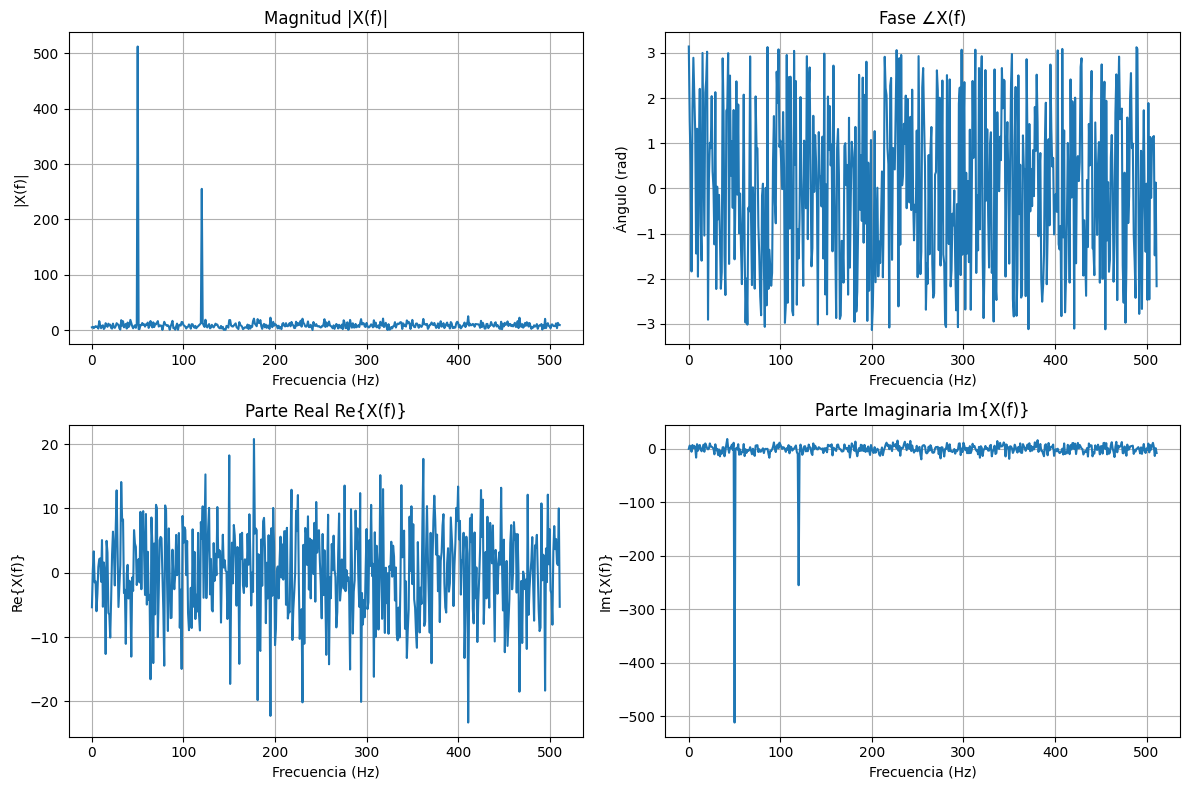

In [2]:
# Señal determinística + ruido gaussiano
signal = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
signal += 0.3*torch.randn(N)

# FFT
fft_signal = torch.fft.fft(signal)

# Magnitud y fase
magnitude = torch.abs(fft_signal)
phase = torch.angle(fft_signal)
real_part = fft_signal.real
imag_part = fft_signal.imag

# Frecuencias asociadas
freqs = torch.fft.fftfreq(N, d=1/fs)

# Graficar
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(freqs[:N//2], magnitude[:N//2])
plt.title("Magnitud |X(f)|")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("|X(f)|")
plt.grid()

plt.subplot(2,2,2)
plt.plot(freqs[:N//2], phase[:N//2])
plt.title("Fase ∠X(f)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Ángulo (rad)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(freqs[:N//2], real_part[:N//2])
plt.title("Parte Real Re{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Re{X(f)}")
plt.grid()

plt.subplot(2,2,4)
plt.plot(freqs[:N//2], imag_part[:N//2])
plt.title("Parte Imaginaria Im{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Im{X(f)}")
plt.grid()

plt.tight_layout()
plt.show()


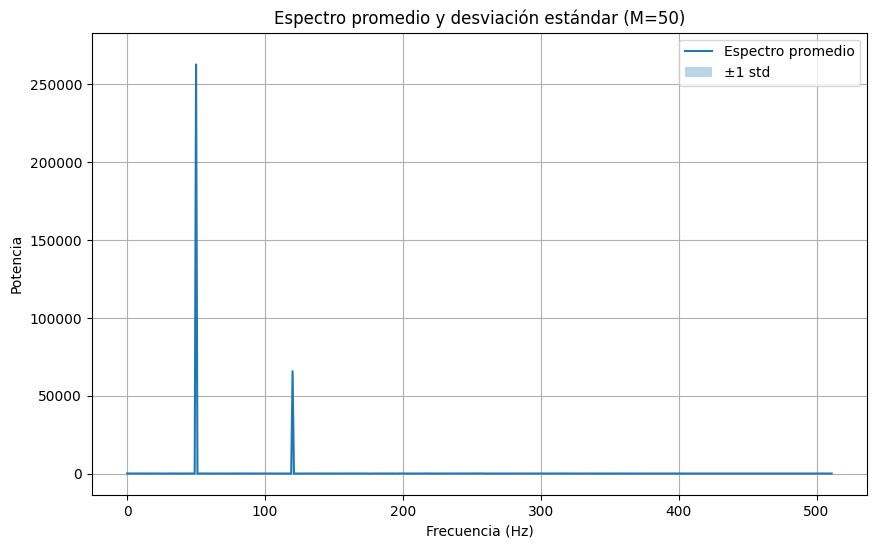

In [3]:
spectra = []

for _ in range(M):
    sig = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    sig += 0.3*torch.randn(N)
    fft_sig = torch.fft.fft(sig)
    spectra.append(torch.abs(fft_sig[:N//2])**2)  # potencia espectral

spectra = torch.stack(spectra)

# Promedio y desviación estándar
mean_spectrum = spectra.mean(dim=0)
std_spectrum = spectra.std(dim=0)

# Graficar
plt.figure(figsize=(10,6))
plt.plot(freqs[:N//2], mean_spectrum, label="Espectro promedio")
plt.fill_between(freqs[:N//2],
                 mean_spectrum-std_spectrum,
                 mean_spectrum+std_spectrum,
                 alpha=0.3, label="±1 std")
plt.title(f"Espectro promedio y desviación estándar (M={M})")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia")
plt.legend()
plt.grid()
plt.show()


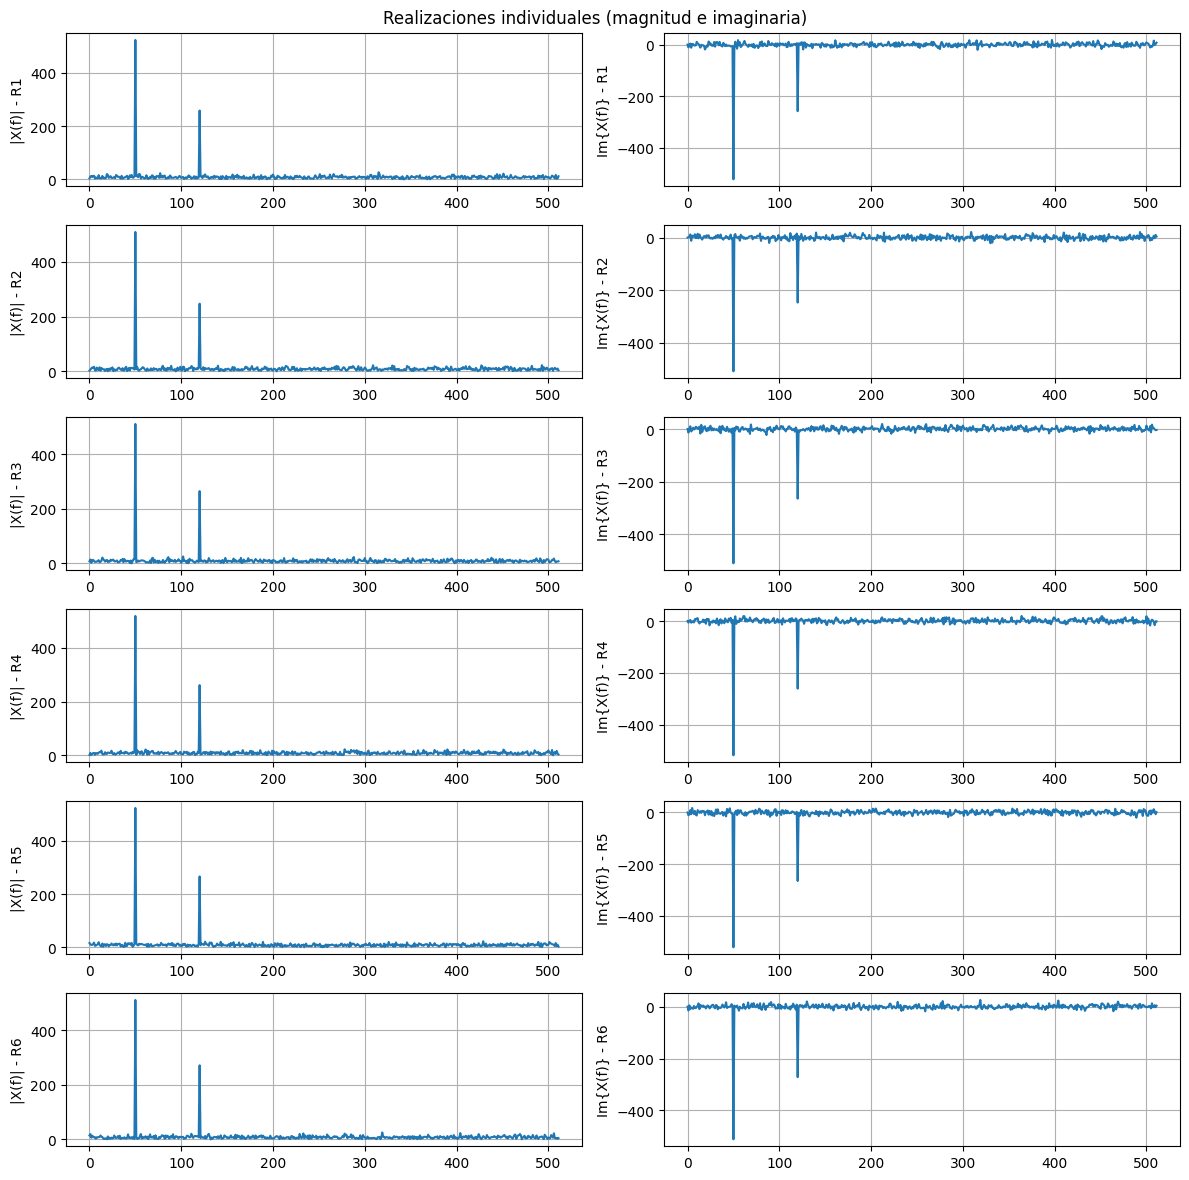

In [4]:
magnitudes, reals, imags = [], [], []

for _ in range(M):
    sig = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    sig += 0.3*torch.randn(N)
    fft_sig = torch.fft.fft(sig)

    magnitudes.append(torch.abs(fft_sig))
    reals.append(fft_sig.real)
    imags.append(fft_sig.imag)

magnitudes = torch.stack(magnitudes)
reals = torch.stack(reals)
imags = torch.stack(imags)

# Mostrar algunas realizaciones
n_mostrar = 6
plt.figure(figsize=(12, 2*n_mostrar))
for i in range(n_mostrar):
    ax = plt.subplot(n_mostrar, 2, 2*i+1)
    ax.plot(freqs[:N//2], magnitudes[i,:N//2])
    ax.set_ylabel(f'|X(f)| - R{i+1}')
    ax.grid()

    ax = plt.subplot(n_mostrar, 2, 2*i+2)
    ax.plot(freqs[:N//2], imags[i,:N//2])
    ax.set_ylabel(f'Im{{X(f)}} - R{i+1}')
    ax.grid()

plt.suptitle("Realizaciones individuales (magnitud e imaginaria)")
plt.tight_layout()
plt.show()


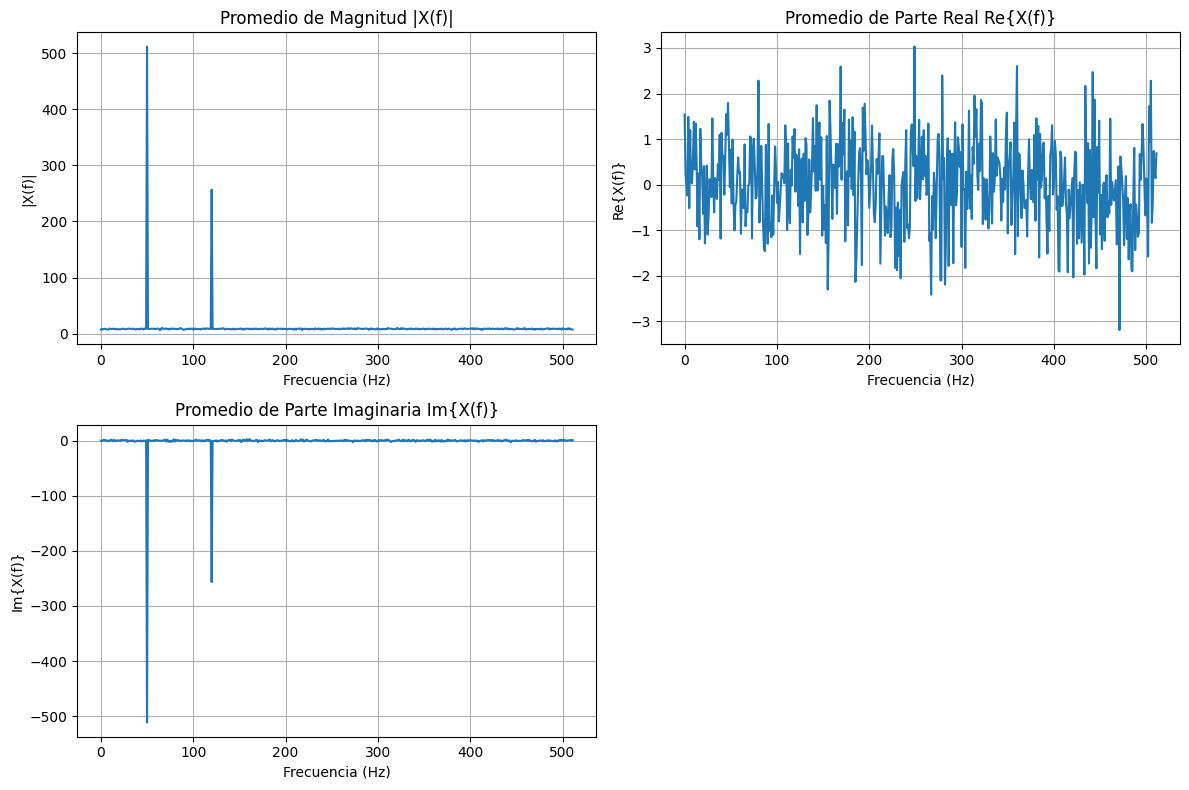

In [5]:
mean_magnitude = magnitudes.mean(dim=0)
mean_real = reals.mean(dim=0)
mean_imag = imags.mean(dim=0)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.plot(freqs[:N//2], mean_magnitude[:N//2])
plt.title("Promedio de Magnitud |X(f)|")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("|X(f)|")
plt.grid()

plt.subplot(2,2,2)
plt.plot(freqs[:N//2], mean_real[:N//2])
plt.title("Promedio de Parte Real Re{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Re{X(f)}")
plt.grid()

plt.subplot(2,2,3)
plt.plot(freqs[:N//2], mean_imag[:N//2])
plt.title("Promedio de Parte Imaginaria Im{X(f)}")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Im{X(f)}")
plt.grid()

plt.tight_layout()
plt.show()


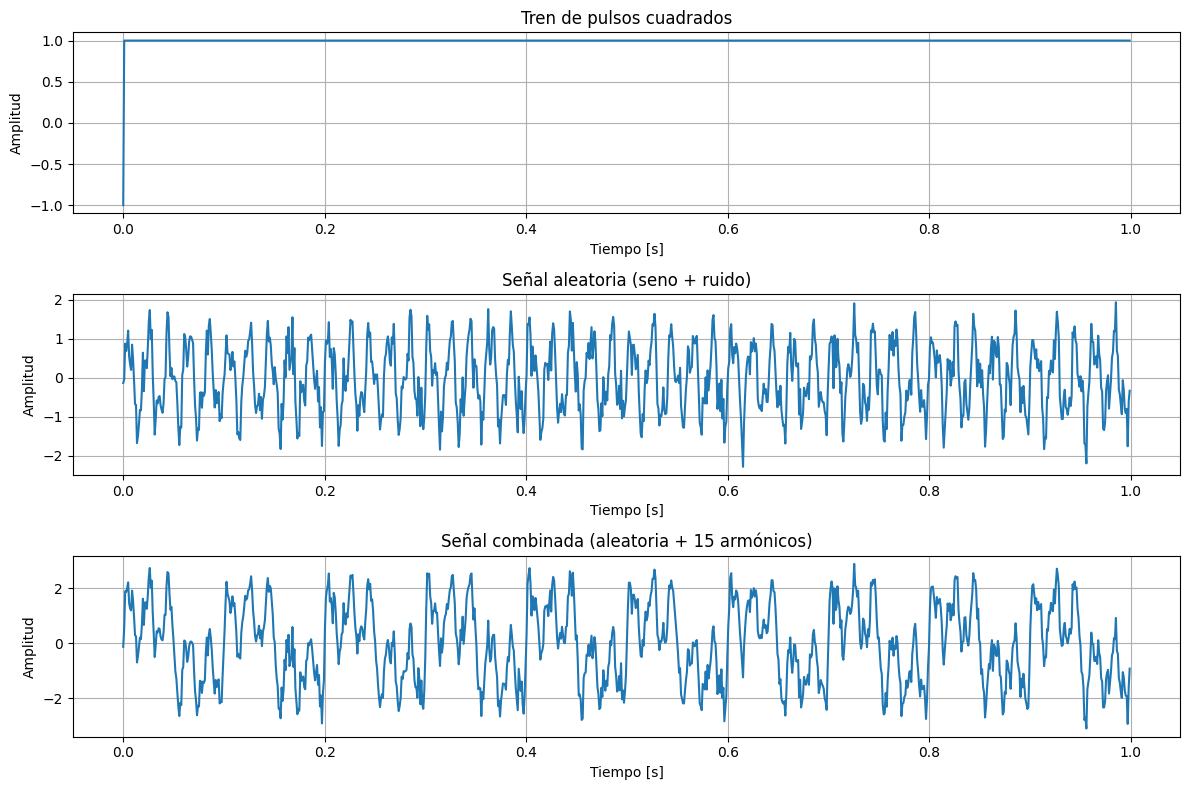

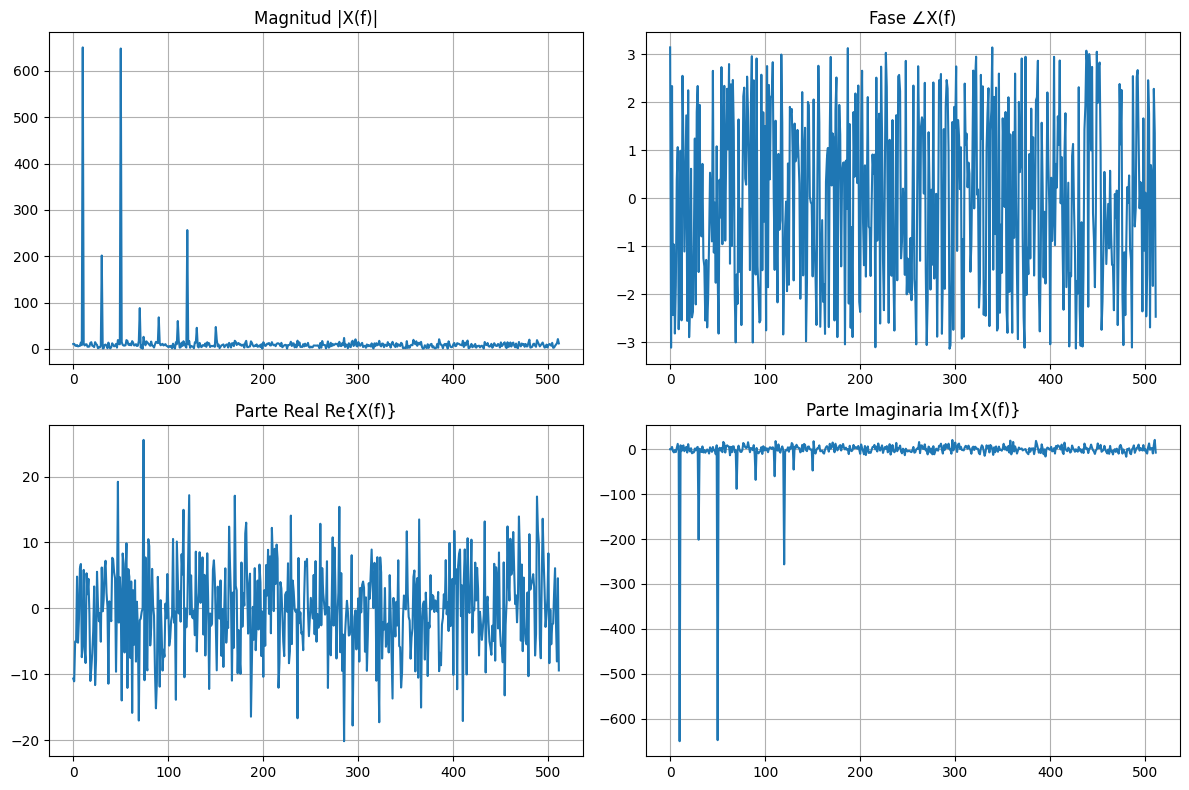

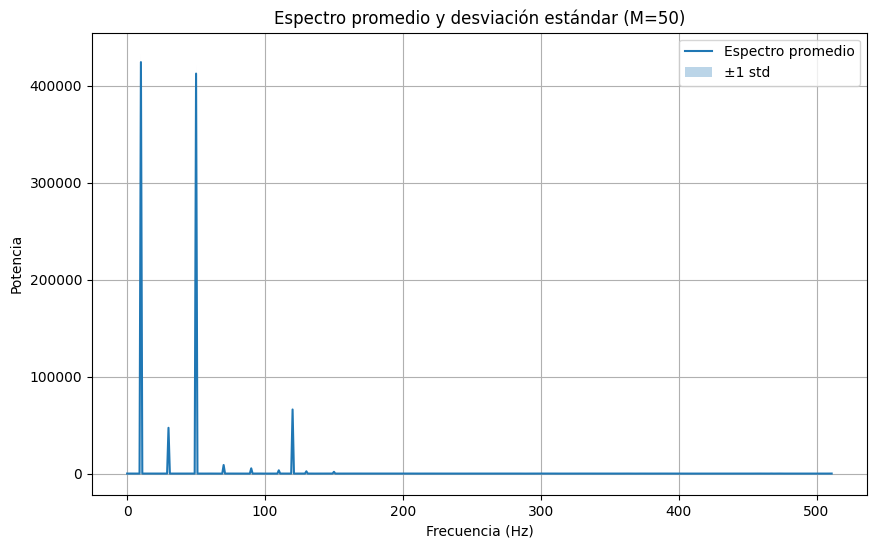

Valor medio del espectro: 1990.136719
Desviación estándar media: 145.658127


In [7]:
import torch
import matplotlib.pyplot as plt

# Parámetros generales
fs = 1024
N = 1024
t = torch.arange(N) / fs
M = 50   # número de realizaciones

# ==============================
# 1. Tren de pulsos cuadrados
# ==============================
duty = 0.3
square_train = torch.square(torch.sin(2*torch.pi*10*t))  # tren de senoidales
square_train = (square_train > 0).float()  # binarizado: tren de pulsos
square_train = 2*square_train - 1  # onda cuadrada bipolar (-1,1)

# ==============================
# 2. Primeros 15 armónicos con serie de Fourier
# ==============================
harmonics = torch.zeros_like(t)
for k in range(1, 16, 2):  # solo armónicos impares
    harmonics += (1/k) * torch.sin(2*torch.pi*k*10*t)
harmonics = (4/torch.pi) * harmonics  # serie de Fourier onda cuadrada

# ==============================
# 3. Señal aleatoria (seno + ruido)
# ==============================
f1, f2 = 50, 120
signal_random = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
signal_random += 0.3*torch.randn(N)

# ==============================
# 4. Señal combinada (aleatoria + armónicos)
# ==============================
signal_combined = signal_random + harmonics

# ==============================
# 5. FFT de la señal combinada
# ==============================
fft_signal = torch.fft.fft(signal_combined)
freqs = torch.fft.fftfreq(N, d=1/fs)

magnitude = torch.abs(fft_signal)
phase = torch.angle(fft_signal)
real_part = fft_signal.real
imag_part = fft_signal.imag

# ==============================
# 6. Múltiples realizaciones
# ==============================
spectra = []
for _ in range(M):
    sig_r = torch.sin(2 * torch.pi * f1 * t) + 0.5*torch.sin(2 * torch.pi * f2 * t)
    sig_r += 0.3*torch.randn(N)
    sig_c = sig_r + harmonics
    fft_sig = torch.fft.fft(sig_c)
    spectra.append(torch.abs(fft_sig[:N//2])**2)

spectra = torch.stack(spectra)
mean_spectrum = spectra.mean(dim=0)
std_spectrum = spectra.std(dim=0)

# ==============================
# 7. Gráficas
# ==============================

plt.figure(figsize=(12,8))
plt.subplot(3,1,1)
plt.plot(t, square_train)
plt.title("Tren de pulsos cuadrados")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, signal_random)
plt.title("Señal aleatoria (seno + ruido)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, signal_combined)
plt.title("Señal combinada (aleatoria + 15 armónicos)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()
plt.tight_layout()
plt.show()

# FFT de la señal combinada
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(freqs[:N//2], magnitude[:N//2])
plt.title("Magnitud |X(f)|")
plt.grid()

plt.subplot(2,2,2)
plt.plot(freqs[:N//2], phase[:N//2])
plt.title("Fase ∠X(f)")
plt.grid()

plt.subplot(2,2,3)
plt.plot(freqs[:N//2], real_part[:N//2])
plt.title("Parte Real Re{X(f)}")
plt.grid()

plt.subplot(2,2,4)
plt.plot(freqs[:N//2], imag_part[:N//2])
plt.title("Parte Imaginaria Im{X(f)}")
plt.grid()
plt.tight_layout()
plt.show()

# Espectro promedio y desviación estándar
plt.figure(figsize=(10,6))
plt.plot(freqs[:N//2], mean_spectrum, label="Espectro promedio")
plt.fill_between(freqs[:N//2],
                 mean_spectrum-std_spectrum,
                 mean_spectrum+std_spectrum,
                 alpha=0.3, label="±1 std")
plt.title(f"Espectro promedio y desviación estándar (M={M})")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia")
plt.legend()
plt.grid()
plt.show()

print(f"Valor medio del espectro: {mean_spectrum.mean().item():.6f}")
print(f"Desviación estándar media: {std_spectrum.mean().item():.6f}")
